<a href="https://colab.research.google.com/github/yoharis1204/analysis_everpeak/blob/main/b912b922_455b_422f_aa28_72fd0875d4a5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Análisis everpeak

In [ ]:
import pandas as pd
df = pd.read_csv("/datasets/everpeak_retail.csv")

## preparación de datos

### Identificando valores faltantes


Objetivo: Contar cuántos valores faltantes tiene cada variable de segmentación y ubicación, usando sumas, no porcentajes.

In [ ]:
payment_missing = df["payment_method"].isna().sum()
city_missing = df["city"].isna().sum()

print("payment_method missing:", payment_missing)
print("city missing:", city_missing)
print("state missing:", state_missing)

payment_method missing: 0
city missing: 100
state missing: 100


### Fechas sospechosas y montos extremos

Objetivo: Medir cuántos registros tienen fechas sospechosas y montos anormalmente altos.

In [ ]:
df["order_date"] = pd.to_datetime(df["order_date"], errors="coerce")

invalid_year_2026_count = (df["order_date"].dt.year == 2026).sum()
missing_order_date_count = df["order_date"].isna().sum()

print("order_date año 2026:", invalid_year_2026_count)
print("order_date missing:", missing_order_date_count)

order_date año 2026: 15
order_date missing: 8


### Cardinalidad en columnas de cliente

Objetivo: Calcular la cardinalidad de columnas clave para entender si son IDs, categorías o variables poco útiles.

In [ ]:
customer_id_unicos = df["customer_id"].nunique()
payment_unicos = df["payment_method"].nunique()
city_unicos = df["city"].nunique()
state_unicos = df["state"].nunique()

print("customer_id nunique:", customer_id_unicos)
print("payment_method nunique:", payment_unicos)
print("city nunique:", city_unicos)
print("state nunique:", state_unicos)

customer_id nunique: 1829
payment_method nunique: 4
city nunique: 10
state nunique: 9


### Detectar patrones de missingness por grupo

# Tipos de Missingness (MCAR, MAR, MNAR)

MCAR — Missing Completely At Random -
La ausencia del dato es completamante al azar, NO depende de ninguna variable ni del valor faltante.


MAR — Missing At Random -
La ausencia es al azar, depende de otra variable observada (pero no del valor faltante en sí).


MNAR — Missing Not At Random -
La ausencia no es al azar, depende del valor faltante o de un proceso no observado.

Objetivo: Evaluar si el missing de city depende de alguna variable del negocio.

In [ ]:
missing_city_by_pay = df["city"].isna().groupby(df["payment_method"]).mean()
print(missing_city_by_pay)

payment_method
cash           0.020101
credit_card    0.021517
debit_card     0.021300
paypal         0.015319
Name: city, dtype: float64


### Comparar impacto entre drop e imputación

Objetivo: Medir cómo cambia la métrica cuando imputas o eliminas datos.

In [ ]:
before = df["order_value"].dropna().mean()
df["order_value_imputed"] = df["order_value"].fillna(df["order_value"].median())
after = df["order_value"].mean()

print(before)
print(after)

10071.564696485622
10071.564696485622


Objetivo: Comparar tres versiones de una columna numérica para decidir la estrategia final.

In [ ]:
import pandas as pd
df = pd.read_csv("/datasets/everpeak_retail.csv")

before = df["customer_age"].mean()

# Creamos "customer_age_med"
df["customer_age_med"] = df["customer_age"].fillna(df["customer_age"].median())
after_med =  df["customer_age_med"].mean()
# Creamos "customer_age_mean"
df["customer_age_mean"] = df["customer_age"].fillna(df["customer_age"].mean())
after_mean =  df["customer_age_mean"].mean()
print(before)
print(after_med)
print(after_mean)

43.72869493618773
43.88658146964856
43.728694936187736


### Convertir a numérico múltiples columnas

Objetivo: crear la función convertir_columnas_numericas con el objetivo de transformar determinadas columnas a tipo numérico. Posteriormente, aplicar la función a una lista denominada columnas_numericas.

In [ ]:
import pandas as pd
df = pd.read_csv('/datasets/everpeak_retail.csv')

def convertir_columnas_numericas(df, columnas):
    for col in columnas:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    return df

# 1. Crear la lista de columnas numéricas
columnas_numericas = ["price", "quantity", "order_value"]

# 2. Aplicar la función convertir_columnas_numericas
df = convertir_columnas_numericas(df, columnas_numericas)

# 3. Revisar resultado
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5008 entries, 0 to 5007
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          5008 non-null   int64  
 1   order_date        5000 non-null   object 
 2   customer_id       5008 non-null   int64  
 3   product_category  5008 non-null   object 
 4   price             5008 non-null   int64  
 5   quantity          5008 non-null   int64  
 6   order_value       5008 non-null   int64  
 7   payment_method    5008 non-null   object 
 8   city              4908 non-null   object 
 9   state             4908 non-null   object 
 10  customer_age      4858 non-null   float64
dtypes: float64(1), int64(5), object(5)
memory usage: 430.5+ KB


### Se agrega una nueva columna a la lista columnas_numericas y se aplica la misma función sin reescribir código

In [ ]:
import pandas as pd
df = pd.read_csv('/datasets/everpeak_retail.csv')

def convertir_columnas_numericas(df, columnas):
    for col in columnas:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    return df

columnas_numericas = ["price", "quantity", "order_value"]

# 1. Agregar la nueva columna
columnas_numericas.append("customer_id")

# 2. Aplicar nuevamente la función
df = convertir_columnas_numericas(df, columnas_numericas)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5008 entries, 0 to 5007
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          5008 non-null   int64  
 1   order_date        5000 non-null   object 
 2   customer_id       5008 non-null   int64  
 3   product_category  5008 non-null   object 
 4   price             5008 non-null   int64  
 5   quantity          5008 non-null   int64  
 6   order_value       5008 non-null   int64  
 7   payment_method    5008 non-null   object 
 8   city              4908 non-null   object 
 9   state             4908 non-null   object 
 10  customer_age      4858 non-null   float64
dtypes: float64(1), int64(5), object(5)
memory usage: 430.5+ KB


### Limpia múltiples columnas de texto con un loop

Objetivo: crear una función que limpia varias columnas categóricas al mismo tiempo eliminando espacios innecesarios

In [ ]:
import pandas as pd
df = pd.read_csv('/datasets/everpeak_retail.csv')
print(df.head())

def step_strip_text(df):
    columnas = ["product_category", "city", "state"]

    # Loop para aplicar strip() a cada columna
    for col in columnas:
        df[col]= df[col].str.strip()

    # Regresar DF limpio
    return df

# Ejecutar para probar
df = step_strip_text(df)
print(df.head())

   order_id  order_date  customer_id product_category  price  quantity  \
0         1  2024-02-02         2616           Sports    269        50   
1         2  2024-10-10         1736          Grocery     66         0   
2         3  2024-08-27         2543           Sports    267         0   
3         4  2024-06-09         2252             Toys    114       125   
4         5  2024-06-07         1583          Fashion    729        16   

   order_value payment_method         city state  customer_age  
0        13385    credit_card     New York    NY          66.0  
1          660     debit_card  Los Angeles    CA          24.0  
2         5073    credit_card      Chicago    IL          23.0  
3        14290    credit_card     New York    NY          70.0  
4        11754    credit_card      Houston    TX          75.0  
   order_id  order_date  customer_id product_category  price  quantity  \
0         1  2024-02-02         2616           Sports    269        50   
1         2  2024

### Crear función para reemplazar Sentinels

Objetivo: Crear una función que reemplace valores sentinels por NaN en una lista de columnas.

In [ ]:
def reemplazar_sentinels(df, sentinels, numeric_cols):
    for col in numeric_cols:
        df[col]= df[col].replace(sentinels, pd.NA)
    return df

import pandas as pd
df = pd.read_csv("/datasets/everpeak_retail.csv")

# observar valores ausentes iniciales
print("Valores ausentes iniciales:")
print(df[["customer_age", "price"]].isna().sum())

# Fijar valores a corregir y columnas
valores_erroneos = [-999, 999, 0, -1]
columnas_numericas = ["price", "customer_age"]

# Aplicar función y observar cambios
df = reemplazar_sentinels(df, valores_erroneos, columnas_numericas)
print("\nValores ausentes después:")
print(df[["customer_age", "price"]].isna().sum())

Valores ausentes iniciales:
customer_age    150
price             0
dtype: int64

Valores ausentes después:
customer_age    175
price             2
dtype: int64


### Función para rellenar ausentes

Objetivo: Crear una función que convierta columnas a tipo numérico y rellene valores ausentes con el promedio.

In [ ]:
# Crear función
def rellenar_ausentes(df, cols_fill):
    for col in cols_fill:# bucle para recorrer columnas
        df[col]= pd.to_numeric(df[col], errors= "coerce")
        df[col].fillna(df[col].mean(), inplace=True)
    return df

import pandas as pd
df = pd.read_csv("/datasets/everpeak_retail.csv")

# observar valores ausentes iniciales
print("Valores ausentes iniciales:")
print(df[["customer_age", "price"]].isna().sum())

# Definir columnas a rellenar
columnas_rellenar = ["customer_age", "price"]

# Aplicar función y observar cambios
df = rellenar_ausentes(df, columnas_rellenar)
print("\nValores ausentes después:")
print(df[["customer_age", "price"]].isna().sum())

Valores ausentes iniciales:
customer_age    150
price             0
dtype: int64

Valores ausentes después:
customer_age    0
price           0
dtype: int64


### Crear Pipeline de limpieza

Objetivo: Crear una función pipeline que orqueste todas las funciones de limpieza en el orden correcto.

In [ ]:
# Crear función pipeline
def limpiar_df(df):


    valores_erroneos= [-999, 999, 0, 1]
    columnas_numericas= ["customer_age", "price"]

    df = reemplazar_sentinels(df, valores_erroneos, columnas_numericas)
    df= rellenar_ausentes(df, columnas_numericas)

    return df

# Importar librería y leer datos
import pandas as pd
df = pd.read_csv("/datasets/everpeak_retail.csv")

# observar valores ausentes iniciales
print("Valores ausentes iniciales:")
print(df[["customer_age", "price"]].isna().sum())

# Aplicar pipeline completo
df = limpiar_df(df)
print("\nValores ausentes después del pipeline:")
print(df[["customer_age", "price"]].isna().sum())

Valores ausentes iniciales:
customer_age    150
price             0
dtype: int64

Valores ausentes después del pipeline:
customer_age    0
price           0
dtype: int64


## Análisis estadístico

In [ ]:
# importar librerías y dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv("/datasets/everpeak_clean.csv")

### Visión general

In [ ]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   order_id               5000 non-null   int64 
 1   order_date             5000 non-null   object
 2   customer_id            5000 non-null   int64 
 3   product_category       5000 non-null   object
 4   price                  5000 non-null   int64 
 5   quantity               5000 non-null   int64 
 6   order_value            5000 non-null   int64 
 7   payment_method         5000 non-null   object
 8   city                   5000 non-null   object
 9   state                  5000 non-null   object
 10  customer_age           5000 non-null   int64 
 11  quantity_invalid_flag  5000 non-null   int64 
 12  age_invalid_flag       5000 non-null   int64 
 13  state_missing_flag     5000 non-null   int64 
dtypes: int64(9), object(5)
memory usage: 547.0+ KB


,order_id,order_date,customer_id,product_category,price,quantity,order_value,payment_method,city,state,customer_age,quantity_invalid_flag,age_invalid_flag,state_missing_flag
0,1,2024-02-02,2616,Sports,269,50,13385,credit_card,New York,NY,66,0,0,0
1,2,2024-10-10,1736,Grocery,66,10,660,debit_card,Los Angeles,CA,24,1,0,0
2,3,2024-08-27,2543,Sports,267,19,5073,credit_card,Chicago,IL,23,1,0,0
3,4,2024-06-09,2252,Toys,114,125,14290,credit_card,New York,NY,70,0,0,0
4,5,2024-06-07,1583,Fashion,729,16,11754,credit_card,Houston,TX,75,0,0,0


Las columnas price, quantity, order_value y customer_age son de tipo INT.

Las analizamos porque permiten identificar patrones, distribuciones y valores atípicos útiles para el análisis.

### Estadisticas descriptivas

#### Resumen numérico categorías Fashion y Sports

Objetivo: crear una visión rápida del desempeño de las categorías Fashion y Sports para entender su situación actual y detectar posibles anomalías en los datos.

In [ ]:
import pandas as pd

df = pd.read_csv('/datasets/everpeak_clean.csv')

# Crear dataframes para cada categoría
df_fashion = df[df["product_category"] == "Fashion"]
df_sports = df[df["product_category"] == "Sports"]

# --- Resumen de columnas numéricas con describe()
columnas_numericas = ['order_value', 'customer_age', 'price', 'quantity']

print('Resumen estadístico de la categoría Fashion')
print(df_fashion[columnas_numericas].describe())

print()#Salto de Línea
print('Resumen estadístico de la categoría Sports')
print(df_sports[columnas_numericas].describe())

Resumen estadístico de la categoría Fashion
         order_value  customer_age         price     quantity
count     739.000000    739.000000    739.000000   739.000000
mean     8745.139378     48.066306    585.863329    24.124493
std     10318.954880     18.083657    655.641761    72.380942
min       122.000000     18.000000     25.000000     1.000000
25%      2913.000000     32.000000    274.500000     8.000000
50%      8115.000000     47.000000    457.000000    14.000000
75%     12527.000000     64.000000    680.000000    21.000000
max    224884.000000     80.000000  11836.000000  1835.000000

Resumen estadístico de la categoría Sports
        order_value  customer_age        price    quantity
count    702.000000    702.000000   702.000000  702.000000
mean   10365.264957     49.742165   839.692308   21.099715
std     8820.536231     17.437736   848.292770   47.126458
min      195.000000     18.000000    47.000000    1.000000
25%     4308.750000     36.000000   347.000000    7.000000


#### Promedio vs Mediana del gasto (Grocery)

Objetivo: Para entender si el gasto típico de los clientes que compran productos de supermercado está siendo afectado por outliers se compara la media y la mediana de la columna order_value para evaluar si hay valores extremos influyendo en el análisis.

In [ ]:
import pandas as pd
df = pd.read_csv('/datasets/everpeak_clean.csv')

# Filtrar la categoría Grocery
df_grocery = df[df["product_category"] == "Grocery"]

# Calcular media y mediana del gasto
promedio = df["order_value"].mean()
mediana = df["order_value"].median()

# Mostrar resultados
print("Promedio del gasto en Grocery:", promedio)
print("Mediana del gasto en Grocery:", mediana)

# Interpretación según comparación de media y mediana
print("El promedio representa el gasto típico de los clientes en Grocery.")

Promedio del gasto en Grocery: 10075.5238
Mediana del gasto en Grocery: 10341.0
El promedio representa el gasto típico de los clientes en Grocery.


#### Promedio vs Mediana (Quantity)

Objetivo: comparar la  media y la mediana de la columna quantity para evaluar si los valores extremos están afectando el análisis de la cantidad típica comprada por los clientes.

In [ ]:
# Promedio y mediana de quantity
print("Promedio de quantity: ", df["quantity"].mean())# tu código aquí)
print("Mediana de quantity: ", df["quantity"].median())# tu código aquí)
print("El promedio está afectado por los outliers o valores atípicos.")# tu interpretación aquí)

Promedio de quantity:  32.3598
Mediana de quantity:  14.0
El promedio está afectado por los outliers o valores atípicos.


#### Resumen numérico por ciudad

Objetivo: crear un resumen estadístico de las cidades de New york y Los Angeles, para tener una visión rápida del comportamiento de los clientes en estas ciudades, comprender su situación actual y detectar posibles anomalías en los datos.

In [ ]:
# Crear dataframes para cada categoría
df_ny = df[df["city"] == "New York"]
df_la = df[df["city"] == "Los Angeles"]

# --- Resumen de columnas numéricas con describe()
columnas_numericas = ['order_value', 'customer_age', 'price', 'quantity']

print('Resumen estadístico de la ciudad New York')
print(df_ny[columnas_numericas].describe())

print()#Salto de Línea
print('Resumen estadístico de la ciudad Los Angeles')
print(df_la[columnas_numericas].describe())

Resumen estadístico de la ciudad New York
         order_value  customer_age         price     quantity
count     497.000000    497.000000    497.000000   497.000000
mean    10545.410463     49.847082    741.454728    40.800805
std     13914.329615     17.507624   1105.570500   147.484959
min        58.000000     18.000000     12.000000     1.000000
25%      2862.000000     35.000000    203.000000     8.000000
50%     10682.000000     49.000000    457.000000    14.000000
75%     13327.000000     64.000000    787.000000    24.000000
max    224884.000000     80.000000  11836.000000  2083.000000

Resumen estadístico de la ciudad Los Angeles
         order_value  customer_age         price     quantity
count     510.000000    510.000000    510.000000   510.000000
mean    10449.945098     49.741176    751.674510    39.511765
std     15979.195581     17.670518   1175.722235   128.503594
min        44.000000     18.000000     13.000000     1.000000
25%      3160.500000     35.000000    202.50

#### Resumen categórico

Objetivo: crear un resumen categórico con registros de las ciudades de New York y otro de Chicago, para entender la distribución de los métodos de pago y las categorías de producto, para identificar patrones dominantes, diversidad de categorías y posibles anomalías.

In [ ]:
#  Columnas categóricas
columnas_categoricas = ['payment_method', 'product_category']

# Filtra por ciudad
df_ny = df[df["city"] == "New York"]
df_chicago = df[df["city"] == "Chicago"]

# Resumen categórico New York
print("Resumen categórico - New York")
print(df_ny[columnas_categoricas].describe())
print() # salto de línea

# Resumen categórico Chicago
print("Resumen categórico - Chicago")
print(df_chicago[columnas_categoricas].describe())

Resumen categórico - New York
       payment_method product_category
count             497              497
unique              4                8
top       credit_card             Toys
freq              271               76

Resumen categórico - Chicago
       payment_method product_category
count             482              482
unique              4                8
top       credit_card             Toys
freq              284               74


 #### Distribución completa de categorías con value_counts()

Objetivo: Revisar todas las categorías de una columna junto con su frecuencia y calcular también los porcentajes.

In [ ]:
columnas_categoricas = ['product_category', 'payment_method', 'city', 'state']

# --- Distribución completa de columnas categóricas usando for
for col in columnas_categoricas:
    print(col)
    print("Frecuencia absoluta")
    print(df[col].value_counts())
    print("Frecuencia relativa")
    print(df[col].value_counts(normalize=True))
    print()


product_category
Frecuencia absoluta
Fashion        739
Electronics    735
Beauty         721
Toys           715
Sports         702
Grocery        684
Home           679
?               25
Name: product_category, dtype: int64
Frecuencia relativa
Fashion        0.1478
Electronics    0.1470
Beauty         0.1442
Toys           0.1430
Sports         0.1404
Grocery        0.1368
Home           0.1358
?              0.0050
Name: product_category, dtype: float64

payment_method
Frecuencia absoluta
credit_card    2737
paypal         1175
debit_card      889
cash            199
Name: payment_method, dtype: int64
Frecuencia relativa
credit_card    0.5474
paypal         0.2350
debit_card     0.1778
cash           0.0398
Name: payment_method, dtype: float64

city
Frecuencia absoluta
Houston          513
Seattle          513
Los Angeles      510
New York         497
Miami            493
Phoenix          491
Chicago          482
Boston           474
San Francisco    467
Denver           460
unknown

#### Resumen categórico (Toys)

Objetivo: Entender la distribución de los métodos de pago y las ciudades asociadas a la categoría Toys, para identificar patrones dominantes, diversidad de ciudades y posibles anomalías.

In [ ]:
# Columnas categóricas
columnas_categoricas = ['payment_method', 'city']

# Filtra por categoría
df_toys = df[df["product_category"] == "Toys"] # Escribe tu código aquí]

# Resumen categórico Toys
print("Resumen categórico - Toys")
print(df_toys[columnas_categoricas].describe())# Escribe tu código aquí)

Resumen categórico - Toys
       payment_method     city
count             715      715
unique              4       11
top       credit_card  Seattle
freq              383       81


#### Distribución completa de ciudades con value_counts() (Sports)

Objetivo: Revisar todas las ciudades asociadas a la categoría Sports, mostrando su frecuencia absoluta y su frecuencia relativa para entender la distribución de ubicaciones dentro de esta categoría.

In [ ]:
# Filtra por categoría
df_sports = df[df["product_category"] == "Sports"]

# Distribución de city
print("Frecuencia absoluta")
print(df_sports["city"].value_counts())
print("\nFrecuencia relativa")
print(df_sports["city"].value_counts(normalize=True))

Frecuencia absoluta
San Francisco    85
Los Angeles      84
Miami            74
New York         74
Denver           68
Seattle          67
Boston           66
Chicago          60
Houston          59
Phoenix          55
unknown          10
Name: city, dtype: int64

Frecuencia relativa
San Francisco    0.121083
Los Angeles      0.119658
Miami            0.105413
New York         0.105413
Denver           0.096866
Seattle          0.095442
Boston           0.094017
Chicago          0.085470
Houston          0.084046
Phoenix          0.078348
unknown          0.014245
Name: city, dtype: float64


### Visualización diagnóstica

#### Analizando la distribución de precios

Objetivo: Entender cómo se distribuyen los precios y detectar posibles valores atípicos que puedan afectar los análisis.

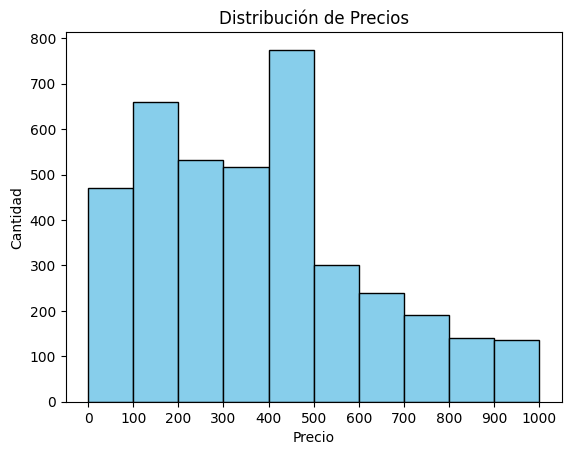

In [ ]:
counts, bin_edges, _ = plt.hist(df["price"], bins=10, range=(0, 1000), color='skyblue', edgecolor='black')# Escribe tu código aquí

# Mostrar las marcas de los bins en el eje X
plt.xticks(bin_edges)# Escribe tu código aquí

# Etiquetas y título del gráfico
plt.xlabel("Precio")# tu código aquí)
plt.ylabel("Cantidad")# tu código aquí)
plt.title("Distribución de Precios")# tu código aquí)
plt.show()

#### Explorando la dispersión de cantidades con Boxplot

Objetivo: Analizar cómo se distribuyen las cantidades compradas (quantity) dentro de la categoría "Toys", para detectar valores extremos que podrían afectar decisiones de inventario y logística.

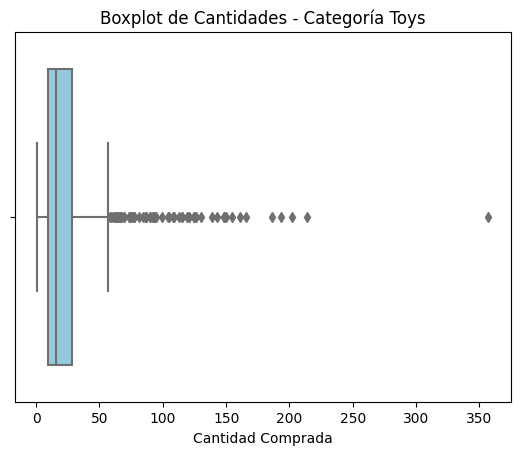

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/datasets/everpeak_clean.csv')

df_toys = df[df["product_category"] == "Toys"]

# Graficar BoxPlot
sns.boxplot(x= df_toys["quantity"], color="skyblue"),

plt.xlabel("Cantidad Comprada")# Etiquetas y título del gráfico
plt.title("Boxplot de Cantidades - Categoría Toys")

plt.show()


#### Distribución de edades de clientes

Objetivo: Entender la distribución de las edades de los clientes (customer_age) para segmentar mejor las estrategias de marketing.

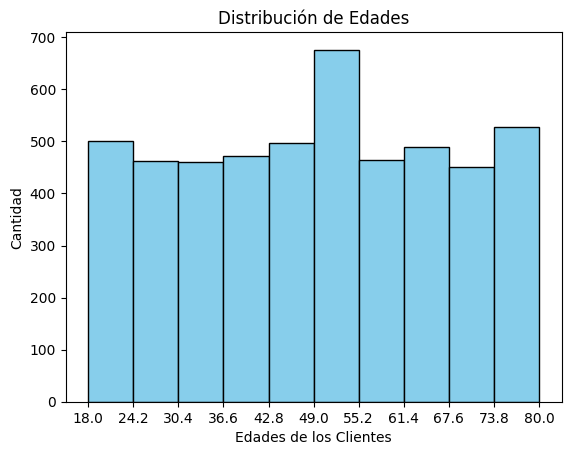

In [ ]:
counts, bin_edges, _ = plt.hist(df["customer_age"], bins=10, color='skyblue', edgecolor='black') # tu código aquí

# Mostrar las marcas de los bins en el eje X
plt.xticks(bin_edges)

# Etiquetas y título del gráfico
plt.xlabel("Edades de los Clientes")
plt.ylabel("Cantidad")
plt.title("Distribución de Edades")
plt.show()

#### Boxplot del valor total de pedidos

Objetivo: analizar cuánto gastan los clientes en las categorías “Fashion” y “Sports”, evaluando la dispersión del order_value y detectando posibles outliers que puedan afectar decisiones de negocio.

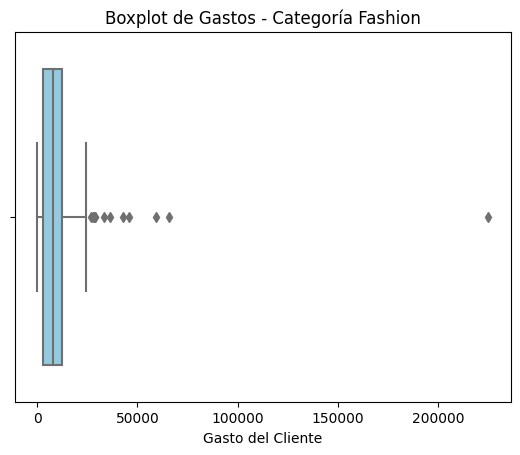

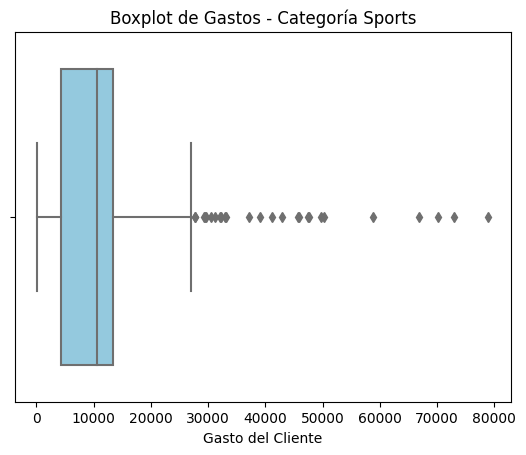

In [ ]:
# Filtrar datos
df_fashion = df[df["product_category"] == "Fashion"]
df_sports = df[df["product_category"] == "Sports"]

# BoxPlot Categoría Fashion
sns.boxplot(x= df_fashion["order_value"], color="skyblue")
plt.xlabel("Gasto del Cliente")# tu código aquí)
plt.title("Boxplot de Gastos - Categoría Fashion")
plt.show()

# BoxPlot Categoría Sports
sns.boxplot(x= df_sports["order_value"], color="skyblue")
plt.xlabel("Gasto del Cliente")# tu código aquí)
plt.title("Boxplot de Gastos - Categoría Sports")
plt.show()

### Identificación formal de outliers

#### Detectar outliers con IQR

 Objetivo: Identificar outliers en order_value con IQR.

In [ ]:
import pandas as pd
df = pd.read_csv("/datasets/everpeak_clean.csv")

# calcular Q1, Q3 e IQR
Q1 = df["order_value"].quantile(0.25)# tu código aquí
Q3 = df["order_value"].quantile(0.75)# tu código aquí
IQR = Q3 - Q1# tu código aquí

# calcular límite inferior y superior
limite_inferior = Q1 - 1.5 * IQR# tu código aquí
limite_superior = Q3 + 1.5 * IQR## tu código aquí

# Mostrar resultados
print('Primer cuartil: ', Q1)
print('Tercer cuartil: ', Q3)
print('IQR: ', IQR)

print("\nRegistros abajo del límite inferior")
print(df[df["order_value"] < limite_inferior])# tu código aquí])

print("\nRegistros arriba del límite superior")
print(df[df["order_value"] > limite_superior])#

Primer cuartil:  3094.0
Tercer cuartil:  13160.5
IQR:  10066.5

Registros abajo del límite inferior
Empty DataFrame
Columns: [order_id, order_date, customer_id, product_category, price, quantity, order_value, payment_method, city, state, customer_age, quantity_invalid_flag, age_invalid_flag, state_missing_flag]
Index: []

Registros arriba del límite superior
      order_id  order_date  customer_id product_category  price  quantity  \
8            9  2024-03-14         2925           Beauty     55       833   
123        124  2024-06-21         1389      Electronics   1947        16   
155        156  2024-08-30         2901          Grocery     36      1278   
199        200  2024-12-18         2919          Fashion   5174         7   
265        266  2024-07-31         1905      Electronics   2897        10   
...        ...         ...          ...              ...    ...       ...   
4934      4935  2024-05-19         1502      Electronics   4282        11   
4936      4937  2024-12

#### Z-scores

Objetivo: Identificar outliers en order_value usando Z-Score.

In [ ]:
import pandas as pd
df = pd.read_csv("/datasets/everpeak_clean.csv")

#cálculo de la media
mean = df["order_value"].mean()# tu código aquí

#cálculo de la desviación estándar
std = df["order_value"].std()# tu código aquí

#Crea el z score
df['z'] = (df["order_value"] - mean) / std# tu código aquí

#Calcula los valores extremos
print(df[df["z"].abs() > 3])# tu código aquí])

      order_id  order_date  customer_id product_category  price  quantity  \
293        294  2024-05-01         2149      Electronics   3336        17   
369        370  2024-10-09         2784      Electronics   5973        13   
375        376  2024-02-04         2285      Electronics   4782        20   
391        392  2024-03-06         2981      Electronics   2463        20   
397        398  2024-03-12         2024      Electronics   4893        18   
...        ...         ...          ...              ...    ...       ...   
4698      4699  2024-04-20         2059      Electronics   5227        11   
4732      4733  2024-10-06         2685           Sports   3394        14   
4908      4909  2024-10-19         1119      Electronics   3927        19   
4921      4922  2024-11-15         1621           Sports   2765        18   
4942      4943  2024-11-02         1979      Electronics   6478        11   

      order_value payment_method      city    state  customer_age  \
293   

#### Comparar métodos en price

Objetivo: Comparar métodos IQR y Z-Score en la columna price.

In [ ]:
import pandas as pd
df = pd.read_csv("/datasets/everpeak_clean.csv")

# ----- IQR -----
# calcular Q1, Q3 e IQR
Q1 = df["price"].quantile(0.25)# tu código aquí
Q3 = df["price"].quantile(0.75)## tu código aquí
IQR = Q3 - Q1# tu código aquí

# calcular límite inferior y superior
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# ----- Z-score -----
# calcular media, desviación estándar y z-score
mean = df["price"].mean()# tu código aquí
std = df["price"].std()# tu código aquí
df['z'] = (df["price"] - mean) / std# tu código aquí

# ----- Mostrar resultados -----
print('Outliers usando IQR:')
print(df[ (df["price"] < lower) | (df["price"] > upper)])# tu código aquí) | (# tu código aquí)])

print('\nOutliers usando Z-Score:')
print(df[df["z"].abs() > 3])# tu código aquí])

Outliers usando IQR:
      order_id  order_date  customer_id product_category  price  quantity  \
64          65  2024-05-30         1651           Sports   2106         5   
67          68  2024-05-15         2385             Home   5181         4   
95          96  2024-04-15         2991           Sports   1940         4   
123        124  2024-06-21         1389      Electronics   1947        16   
138        139  2024-05-07         2274      Electronics   2437         6   
...        ...         ...          ...              ...    ...       ...   
4955      4956  2024-03-11         2230      Electronics   3824         6   
4974      4975  2024-10-20         2627      Electronics   1985         6   
4984      4985  2024-03-11         2509           Sports   1911         4   
4990      4991  2024-08-25         2569           Sports   2856         5   
4997      4998  2024-10-26         2838      Electronics   2699         4   

      order_value payment_method         city    state

### Clasificación y tratamiento de outliers: Drop, Keep o Cap

Drop: cuando el valor es imposible

Keep: es un valor posible a mantener

Winsorization: cuando es extremo pero posible

#### Winsorization (valores extremos pero posibles)

Para conservar la información del cliente típico, capamos los valores que estén por encima del percentil del 99.

In [ ]:
num_cols = ["price", "quantity", "order_value", "customer_age"]
df[num_cols].describe()

for col in num_cols:
    p99 = df[col].quantile(0.99)
    df[f'{col}_capped'] = np.clip(df[col], None, p99)

df[["price","price_capped", "quantity","quantity_capped",
    "order_value","order_value_capped", "customer_age","customer_age_capped"]].head()

,price,price_capped,quantity,quantity_capped,order_value,order_value_capped,customer_age,customer_age_capped
0,269,269.0,50,50.0,13385,13385.0,66,66
1,66,66.0,10,10.0,660,660.0,24,24
2,267,267.0,19,19.0,5073,5073.0,23,23
3,114,114.0,125,125.0,14290,14290.0,70,70
4,729,729.0,16,16.0,11754,11754.0,75,75


### Estadísticas post-tratamiento

In [ ]:
df[["price","price_capped", "quantity","quantity_capped",
    "order_value","order_value_capped", "customer_age","customer_age_capped"]].describe()

,price,price_capped,quantity,quantity_capped,order_value,order_value_capped,customer_age,customer_age_capped
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,756.387400,725.998400,32.359800,27.930100,10075.523800,9694.762100,49.120800,49.120800
std,1173.265182,877.342942,93.403826,48.505516,12406.603152,8677.328642,17.710679,17.710679
min,12.000000,12.000000,1.000000,1.000000,12.000000,12.000000,18.000000,18.000000
25%,218.000000,218.000000,7.000000,7.000000,3094.000000,3094.000000,34.000000,34.000000
50%,457.000000,457.000000,14.000000,14.000000,10341.000000,10341.000000,49.000000,49.000000
75%,847.250000,847.250000,23.000000,23.000000,13160.500000,13160.500000,64.000000,64.000000
max,36708.000000,5148.120000,2083.000000,331.010000,303824.000000,56150.670000,80.000000,80.000000


### Conclusión ejecutiva

#### Columna price:

• El 50% de los precios se encuentra entre 218 y 847.

• Los valores >847 USD corresponden al 25% de los precios más altos.

• Se realizó winsorización al percentil 99 para estabilizar métricas sin perder estos segmentos.


#### Columna price_capped:

Después del proceso de capping, la variabilidad disminuye (std = 877) y el valor máximo se reduce a 5148.

Esto indica que el tratamiento de valores extremos ayudó a estabilizar la distribución sin alterar significativamente los cuartiles ni la mediana.

#### Columna quantity:

La mayoría de las cantidades se concentra entre 7 y 23 unidades; sin embargo, existen valores extremos (2083) que elevan considerablemente la desviación estándar (93).

La distribución muestra un fuerte sesgo positivo.

#### Columna quantity_capped:

Tras limitar los valores extremos, el máximo disminuye a 331 y la dispersión se reduce notablemente (std = 48).

Esto permite una representación más estable y menos influenciada por anomalías.

#### Columna order_value:

Es la variable con mayor dispersión (std = 12406).

Aunque el 50% de los pedidos tiene valores cercanos a 10341, existen pedidos excepcionalmente altos (303824) que afectan la media y reflejan una fuerte presencia de outliers.

#### Columna order_value_capped:

El capping reduce significativamente el impacto de los valores extremos, disminuyendo tanto el máximo (56150) como la desviación estándar (8677).

La distribución sigue siendo asimétrica, pero más controlada y representativa del comportamiento general.

#### Columna customer_age:

Presenta una distribución bastante estable y equilibrada.

La media (49.1) y la mediana (49) son prácticamente iguales, lo que sugiere poca asimetría y ausencia de valores atípicos relevantes.

#### Columna customer_age_capped:

Mantiene exactamente las mismas métricas descriptivas que la variable original, lo que indica que no existían outliers significativos en la edad de los clientes y, por tanto, el capping no produjo cambios.